In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import time

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.12.1+cu126
CUDA: True
Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [2]:
PROCESSED_DIR = Path("../data/processed")
CHECKPOINT_DIR = Path("../outputs/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 8
EPOCHS = 20
LR = 1e-4
NUM_WORKERS = 0
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [3]:
for split in ["train", "val", "test"]:
    n = len(list((PROCESSED_DIR / split / "inputs").glob("*.npy")))
    print(split, n)

train 11736
val 2515
test 2516


In [4]:
class LandsatPatchDataset(Dataset):
    def __init__(self, processed_dir, split):
        self.input_dir = Path(processed_dir) / split / "inputs"
        self.target_dir = Path(processed_dir) / split / "targets"

        self.input_files = sorted(self.input_dir.glob("*.npy"))
        self.target_files = sorted(self.target_dir.glob("*.npy"))

        assert len(self.input_files) == len(self.target_files), "Input/target count mismatch"

    def __len__(self):
        return len(self.input_files)

    def __getitem__(self, idx):
        inp = np.load(self.input_files[idx]).astype(np.float32)
        tgt = np.load(self.target_files[idx]).astype(np.float32)

        inp = torch.from_numpy(inp).permute(2, 0, 1)
        tgt = torch.from_numpy(tgt).permute(2, 0, 1)

        return inp, tgt

In [5]:
train_dataset = LandsatPatchDataset(PROCESSED_DIR, "train")
val_dataset = LandsatPatchDataset(PROCESSED_DIR, "val")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

x, y = next(iter(train_loader))
print("Input batch:", x.shape)
print("Target batch:", y.shape)

Train batches: 1467
Val batches: 315
Input batch: torch.Size([8, 5, 128, 128])
Target batch: torch.Size([8, 3, 128, 128])


In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class PhysicsUNet(nn.Module):
    def __init__(self, in_channels=5, out_channels=3):
        super().__init__()

        self.down1 = DoubleConv(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.down4 = DoubleConv(128, 256)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv4 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, out_channels, kernel_size=1)
        self.activation = nn.Sigmoid()

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        d4 = self.down4(p3)
        p4 = self.pool4(d4)

        bn = self.bottleneck(p4)

        u4 = self.up4(bn)
        u4 = torch.cat([u4, d4], dim=1)
        u4 = self.conv4(u4)

        u3 = self.up3(u4)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return self.activation(self.out(u1))

In [7]:
model = PhysicsUNet(in_channels=5, out_channels=3).to(device)

summary(
    model,
    input_size=(BATCH_SIZE, 5, 128, 128),
    col_names=["input_size", "output_size", "num_params"],
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
PhysicsUNet                              [8, 5, 128, 128]          [8, 3, 128, 128]          --
├─DoubleConv: 1-1                        [8, 5, 128, 128]          [8, 32, 128, 128]         --
│    └─Sequential: 2-1                   [8, 5, 128, 128]          [8, 32, 128, 128]         --
│    │    └─Conv2d: 3-1                  [8, 5, 128, 128]          [8, 32, 128, 128]         1,472
│    │    └─BatchNorm2d: 3-2             [8, 32, 128, 128]         [8, 32, 128, 128]         64
│    │    └─ReLU: 3-3                    [8, 32, 128, 128]         [8, 32, 128, 128]         --
│    │    └─Conv2d: 3-4                  [8, 32, 128, 128]         [8, 32, 128, 128]         9,248
│    │    └─BatchNorm2d: 3-5             [8, 32, 128, 128]         [8, 32, 128, 128]         64
│    │    └─ReLU: 3-6                    [8, 32, 128, 128]         [8, 32, 128, 128]         --
├─MaxPool2d: 1-2             

In [8]:
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)

print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Loss: L1Loss()
Optimizer: Adam


In [9]:
def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    running_loss = 0.0

    for inputs, targets in tqdm(loader, leave=False):

        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, targets)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [10]:
@torch.no_grad()
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0

    for inputs, targets in tqdm(loader, leave=False):

        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        outputs = model(inputs)

        loss = criterion(outputs, targets)

        running_loss += loss.item()

    return running_loss / len(loader)

In [11]:
best_val_loss = float("inf")

train_losses = []
val_losses = []

start_time = time.time()

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.6f}")
    print(f"Val Loss:   {val_loss:.6f}")

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        checkpoint_path = CHECKPOINT_DIR / "best_physics_unet.pth"

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
            },
            checkpoint_path
        )

        print("✅ Best model saved")

elapsed = time.time() - start_time

print("\nTraining Complete")
print(f"Best Val Loss: {best_val_loss:.6f}")
print(f"Time: {elapsed/60:.2f} minutes")


Epoch [1/20]


Train Loss: 0.087377
Val Loss:   0.060787
✅ Best model saved

Epoch [2/20]


Train Loss: 0.066688
Val Loss:   0.057279
✅ Best model saved

Epoch [3/20]


Train Loss: 0.060313
Val Loss:   0.051975
✅ Best model saved

Epoch [4/20]


Train Loss: 0.056247
Val Loss:   0.049346
✅ Best model saved

Epoch [5/20]


...

Train Loss: 0.040764
Val Loss:   0.037843
✅ Best model saved

Epoch [17/20]


Train Loss: 0.040596
Val Loss:   0.037651
✅ Best model saved

Epoch [18/20]


Train Loss: 0.040267
Val Loss:   0.038668

Epoch [19/20]


Train Loss: 0.039656
Val Loss:   0.037257
✅ Best model saved

Epoch [20/20]


Train Loss: 0.039045
Val Loss:   0.036348
✅ Best model saved

Training Complete
Best Val Loss: 0.036348
Time: 628.83 minutes


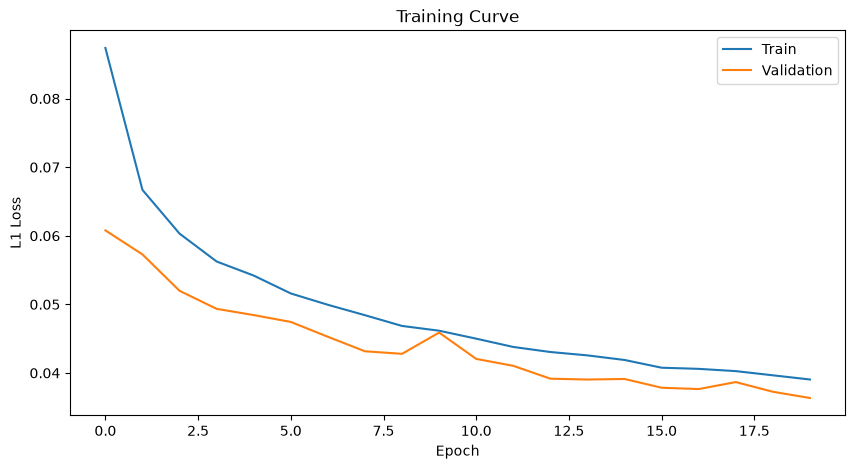

In [12]:
plt.figure(figsize=(10,5))

plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("Training Curve")
plt.legend()

plt.show() 